In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [15]:
entropy_all_file = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/calculated_barcode_entropy_df.tsv'

entropy_all = pd.read_csv(entropy_all_file, sep=',', index_col=0)
print('entropy_all.shape:', entropy_all.shape)
entropy_all.head(2)

entropy_all.shape: (33287, 6)


,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089


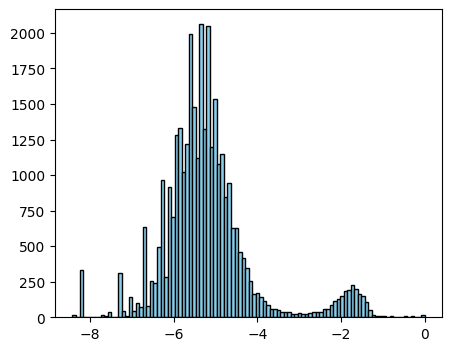

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
_ = ax.hist(np.log(entropy_all['Entropy']), bins=100, color='skyblue', edgecolor='black')

In [27]:
file = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/entropy_filtered_bc_df.tsv'
entropy_df = pd.read_csv(file, sep=',', index_col=0)
print('entropy_df.shape:', entropy_df.shape)

entropy_df.shape: (2101, 7)


In [6]:
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris
CGTGTTTCAAACCTAG-1,0.998157,1.989804,26417,1.111023,0.329222,0.525430,NO
GGAGGCTTCATGGATA-1,0.969950,0.401102,2468,0.077603,0.925332,0.601704,NO


Text(0.5, 1.0, 'Entropy vs MLE Lambda colored Qualified BCs')

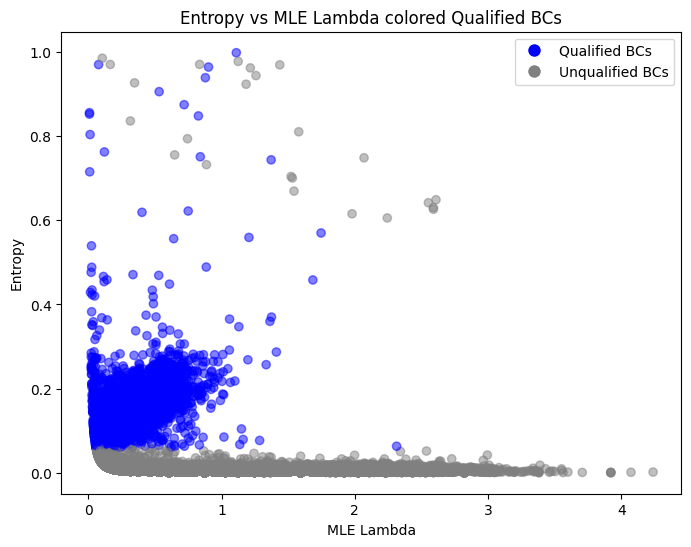

In [7]:
cat_colors = {True: 'blue', False: 'grey'}
fig,ax = plt.subplots(figsize=(8,6))
ax.scatter( entropy_all['mle_lambda'], entropy_all['Entropy'], alpha=0.5, 
           c= entropy_all.apply(lambda x: cat_colors[x.name in entropy_df.index], axis=1))
ax.set_ylabel('Entropy')
ax.set_xlabel('MLE Lambda')
color_legend = [plt.Line2D([0], [0], marker='o', color='w', label='Qualified BCs', 
                       markerfacecolor='blue', markersize=10),
                plt.Line2D([0], [0], marker='o', color='w', label='Unqualified BCs', 
                       markerfacecolor='grey', markersize=10)]
ax.legend(handles=color_legend, loc='upper right')
plt.title('Entropy vs MLE Lambda colored Qualified BCs')

Text(0.5, 1.0, 'Entropy vs MLE Lambda colored Qualified BCs')

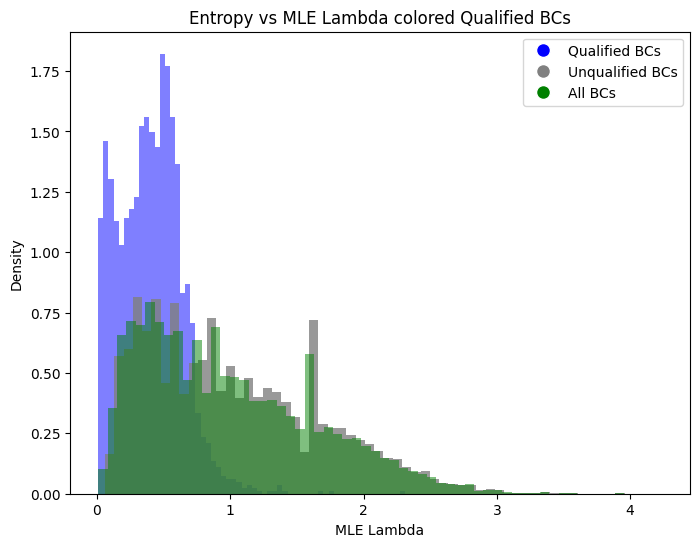

In [8]:
cat_colors = {True: 'blue', False: 'grey'}
fig,ax = plt.subplots(figsize=(8,6))
ax.hist( entropy_all.loc[entropy_all.index.isin(entropy_df.index), 'mle_lambda'] , alpha=0.5, color='blue', density=True, bins=60)
ax.hist( entropy_all.loc[~entropy_all.index.isin(entropy_df.index), 'mle_lambda'] , alpha=0.8, color='grey', density=True, bins=60)
ax.hist( entropy_all[ 'mle_lambda'] , alpha=0.5, color='green', density=True, bins=60)
ax.set_ylabel('Density')
ax.set_xlabel('MLE Lambda')
color_legend = [plt.Line2D([0], [0], marker='o', color='w', label='Qualified BCs', 
                       markerfacecolor='blue', markersize=10),
                plt.Line2D([0], [0], marker='o', color='w', label='Unqualified BCs', 
                       markerfacecolor='grey', markersize=10),
                plt.Line2D([0], [0], marker='o', color='w', label='All BCs', 
                       markerfacecolor='green', markersize=10)]
ax.legend(handles=color_legend, loc='upper right')
plt.title('Entropy vs MLE Lambda colored Qualified BCs')

In [9]:
entropy_all.loc[entropy_all['mle_lambda'] <1]

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089
CCGCTTACATGCAACA-1,0.003783,1.372759,10,0.549861,0.577030,0.999715
CATGAGCCAAGCCTGG-1,0.004177,1.096126,9,0.415723,0.659863,0.999681
TGCGGAATCCTTAGTG-1,0.132542,1.125981,471,0.368123,0.692032,0.981571
GGGATGGAGGGCTATG-1,0.006766,1.548837,23,0.701302,0.495939,0.999450
...,...,...,...,...,...,...
GCTCAATGTCCTTGAG-1,0.003480,1.153582,8,0.464213,0.628630,0.999740
CCAAGTGAGGCGCGAT-1,0.001878,1.253003,4,0.464213,0.628630,0.999870
CACTGTCAGGTGGAAA-1,0.000681,1.562933,2,0.874217,0.417188,0.999959
CGTGCTTAGGTCACGA-1,0.005469,1.474223,18,0.697373,0.497892,0.999568


Text(0.5, 1.0, 'Entropy vs MLE Lambda colored Qualified BCs')

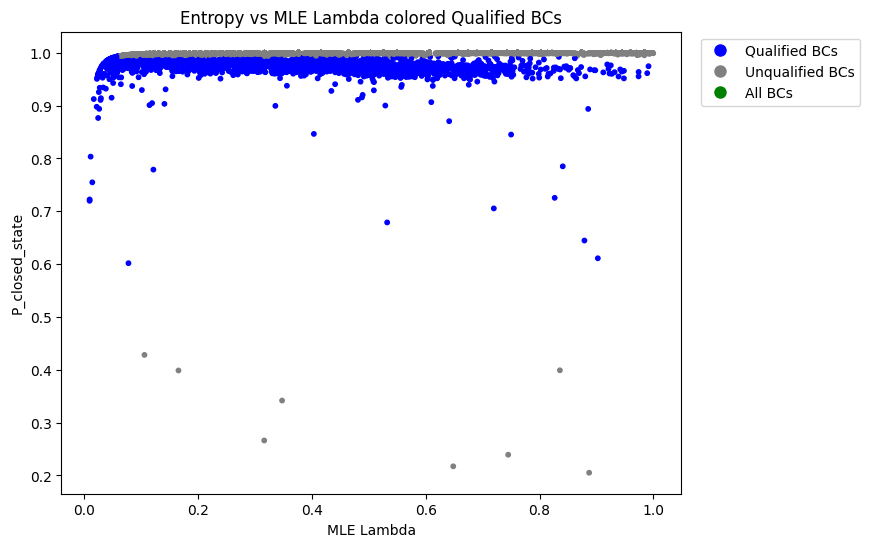

In [10]:
cat_colors = {True: 'blue', False: 'grey'}
fig,ax = plt.subplots(figsize=(8,6))
ax.scatter(entropy_all.loc[entropy_all['mle_lambda'] < 1, 'mle_lambda'], entropy_all.loc[entropy_all['mle_lambda'] < 1, 'P_closed_state'], 
        c= entropy_all.loc[entropy_all['mle_lambda'] <1].apply(lambda x: cat_colors[x.name in entropy_df.index], axis=1), s=10)
ax.set_ylabel('P_closed_state')
ax.set_xlabel('MLE Lambda')
color_legend = [plt.Line2D([0], [0], marker='o', color='w', label='Qualified BCs', 
                       markerfacecolor='blue', markersize=10),
                plt.Line2D([0], [0], marker='o', color='w', label='Unqualified BCs', 
                       markerfacecolor='grey', markersize=10),
                plt.Line2D([0], [0], marker='o', color='w', label='All BCs', 
                       markerfacecolor='green', markersize=10)]
ax.legend(handles=color_legend, loc='upper right', bbox_to_anchor=(1.3, 1))
plt.title('Entropy vs MLE Lambda colored Qualified BCs')

Text(0.5, 1.0, 'Entropy vs MLE Lambda colored by P_closed_state')

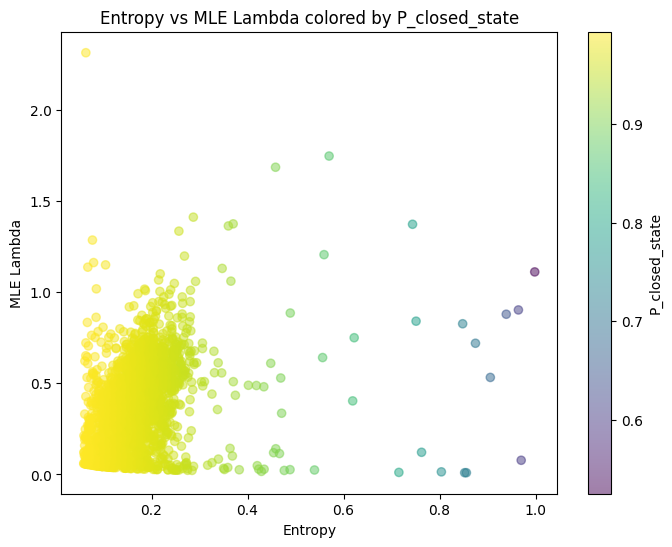

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(entropy_df['Entropy'], entropy_df['mle_lambda'], alpha=0.5, 
           c= entropy_df['P_closed_state'])
ax.set_xlabel('Entropy')
ax.set_ylabel('MLE Lambda')
# add legend for color
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('P_closed_state')
plt.title('Entropy vs MLE Lambda colored by P_closed_state')

# Load entropy calculated with small Poisson rate in closed region 

In [17]:
output_dir_small_lambda_closeregion = '/home/syyang/adipose_ln/atac/res/VIB_10xmultiome_2_WS3000_poissonrate'

entropy_df_file_small_lambda_closeregion = os.path.join(output_dir_small_lambda_closeregion, 'calculated_barcode_entropy_df.tsv')
entropy_df_small_lambda_closeregion = pd.read_csv(entropy_df_file_small_lambda_closeregion, sep=',', index_col=0)
entropy_df_small_lambda_closeregion_nonNA = entropy_df_small_lambda_closeregion.loc[~entropy_df_small_lambda_closeregion['Entropy'].isna()]

In [28]:
entropy_all['entropy_from_HaiyanMethod'] =entropy_all.index.map(entropy_df_small_lambda_closeregion_nonNA['Entropy'])
entropy_all['qualified_bc'] = entropy_all.index.isin(entropy_df.index)

Text(0.5, 1.0, 'Entropy from original method vs Entropy from Small-Poisson-close-region colored Qualified BCs')

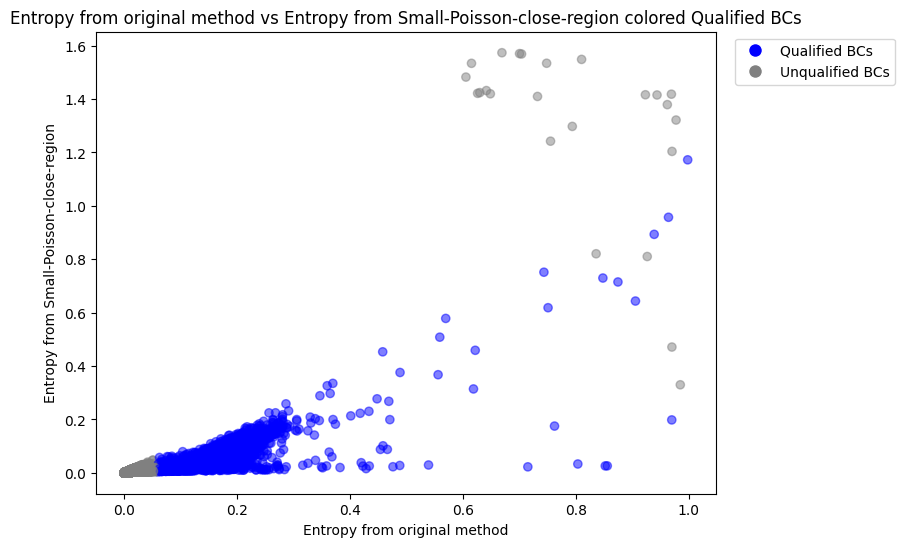

In [38]:
cat_colors = {True: 'blue', False: 'grey'}

fig,ax = plt.subplots(figsize=(8,6))
ax.scatter(entropy_all['Entropy'], entropy_all['entropy_from_HaiyanMethod'], alpha=0.5, 
           c = entropy_all.apply(lambda x: cat_colors[x['qualified_bc']], axis=1))
ax.set_xlabel('Entropy from original method')
ax.set_ylabel('Entropy from Small-Poisson-close-region')
color_legend = [plt.Line2D([0], [0], marker='o', color='w', label='Qualified BCs', 
                       markerfacecolor='blue', markersize=10),
                plt.Line2D([0], [0], marker='o', color='w', label='Unqualified BCs', 
                       markerfacecolor='grey', markersize=10)]
ax.legend(handles=color_legend, loc='upper right', bbox_to_anchor=(1.3, 1))
plt.title('Entropy from original method vs Entropy from Small-Poisson-close-region colored Qualified BCs')

Text(0.5, 0, 'Entropy from Small Poisson rate in close region')

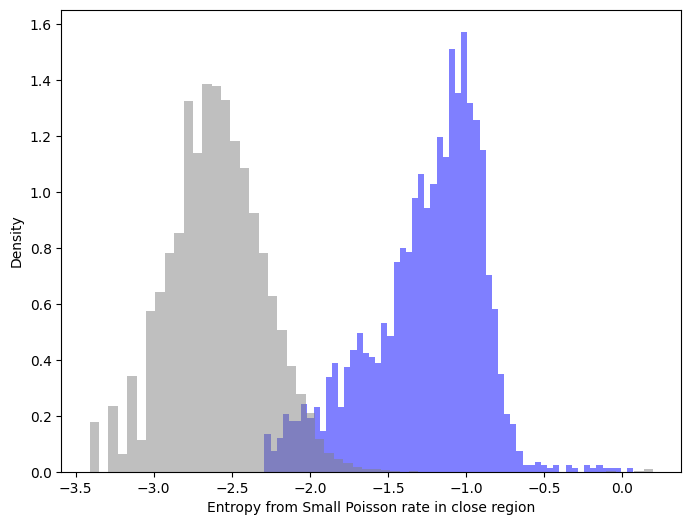

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(np.log10(entropy_all.loc[entropy_all['qualified_bc'], 'entropy_from_HaiyanMethod']), alpha=0.5, color='blue', density=True, bins=60)
ax.hist(np.log10(entropy_all.loc[~entropy_all['qualified_bc'], 'entropy_from_HaiyanMethod']), alpha=0.5, color='grey', density=True, bins=60)
ax.set_ylabel('Density')
ax.set_xlabel('Entropy from Small Poisson rate in close region')

Text(0.5, 0, 'Entropy')

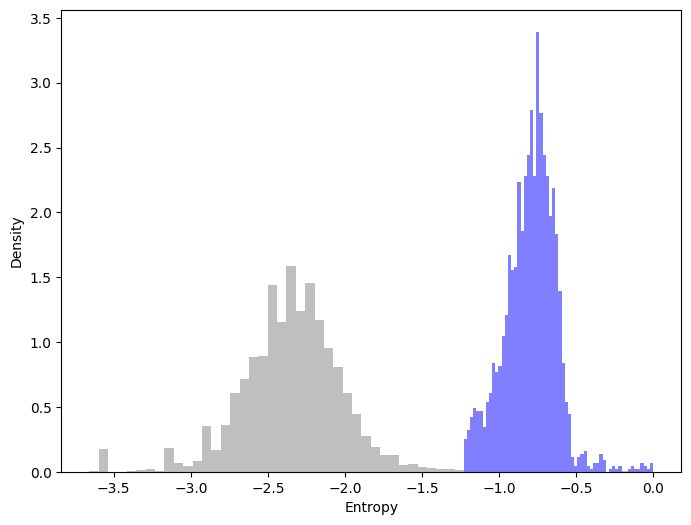

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(np.log10(entropy_all.loc[entropy_all['qualified_bc'], 'Entropy']), alpha=0.5, color='blue', density=True, bins=60)
ax.hist(np.log10(entropy_all.loc[~entropy_all['qualified_bc'], 'Entropy']), alpha=0.5, color='grey', density=True, bins=60)
ax.set_ylabel('Density')
ax.set_xlabel('Entropy')